In [56]:
pip install pandas

In [57]:
import subprocess,sys
for pkg in ['pandas','numpy','matplotlib','seaborn','plotly','openpyxl']:
    subprocess.check_call([sys.executable,'-m','pip','install','pkg','-q'])

print('All libraries are ready!')

All libraries are ready!


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go 
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries imported successfully!')

Libraries imported successfully!


In [59]:
Data =pd.read_excel(r"C:\Users\ADMIN\Downloads\sales_records_dataset.xlsx")

In [60]:
print(f'Dataset loaded! Shape:{Data.shape[0]} rows *{Data.shape[1]}columns')

Dataset loaded! Shape:1000 rows *14columns


In [61]:
Data.head(5)

,Order_ID,Customer_Name,Gender,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Order_Date,Payment_Method,Sales_Rep
0,ORD1001,Zainab James,Female,West,Electronics,Laptop,3.0,21785.0,65355.0,4346.0,11889.607718,2022-07-18,Cash,Rep_D
1,NaN,Zainab Okafor,Male,East,Clothing,Jeans,2.0,69255.0,138510.0,903.0,17920.557815,2024-09-18,Online,Rep_A
2,ORD1003,Samuel Abdullahi,Male,South,Clothing,Shirt,9.0,106459.0,958131.0,171.0,56257.963706,2023-09-11,POS,Rep_C
3,ORD1004,Daniel Balogun,Female,East,Furniture,Bed,5.0,102967.0,514835.0,3286.0,87530.327068,NaN,Cash,Rep_B
4,ORD1005,Ibrahim Khan,Male,West,Electronics,Laptop,7.0,148887.0,1042209.0,741.0,67011.935599,2022-06-03,Transfer,Rep_D


In [62]:
import numpy as np

In [63]:
Data.info

<bound method DataFrame.info of     Order_ID      Customer_Name  Gender Region Product_Category Product_Name  \
0    ORD1001       Zainab James  Female   West      Electronics       Laptop   
1        NaN      Zainab Okafor    Male   East         Clothing        Jeans   
2    ORD1003   Samuel Abdullahi    Male  South         Clothing        Shirt   
3    ORD1004     Daniel Balogun  Female   East        Furniture          Bed   
4    ORD1005       Ibrahim Khan    Male   West      Electronics       Laptop   
..       ...                ...     ...    ...              ...          ...   
995  ORD1996  Ibrahim Abdullahi    Male  South            Books     Notebook   
996  ORD1997          Grace Ola    Male  North      Electronics        Phone   
997  ORD1998       Aisha Okafor    Male  South        Furniture        Chair   
998  ORD1999       Ibrahim Musa  Female   West             Food       Snacks   
999  ORD2000        Tunde James  Female   West         Clothing        Jeans   

     Qu

In [64]:
Data.describe().round(2)

,Quantity,Unit_Price,Total_Sales,Discount,Profit
count,955.00,949.00,942.00,950.00,947.00
mean,5.53,75752.28,424735.26,2513.22,64645.40
std,2.85,42736.95,339359.57,1463.39,61028.39
min,1.00,2037.00,2118.00,0.00,171.57
25%,3.00,38059.00,133941.50,1271.00,17417.64
50%,6.00,76180.00,357334.50,2497.50,46940.54
75%,8.00,112145.00,621387.25,3796.25,93647.07
max,10.00,149555.00,1492040.00,4996.00,356652.16


In [65]:
missing = Data.isnull().sum()
missing_pct = (missing / len(Data) * 100).round(2)

In [66]:
missing_Data= pd.DataFrame({'Missing Count':missing,'Missing %':missing_pct})
missing_Data = missing_Data[m issing_Data['Missing Count'] > 0].sort_values('Missing %',ascending=False)

print('Columns with missing values:')
print(missing_Data.to_string())

SyntaxError: invalid syntax (2806902493.py, line 2)

###### import matplotlib.pyplot as plt

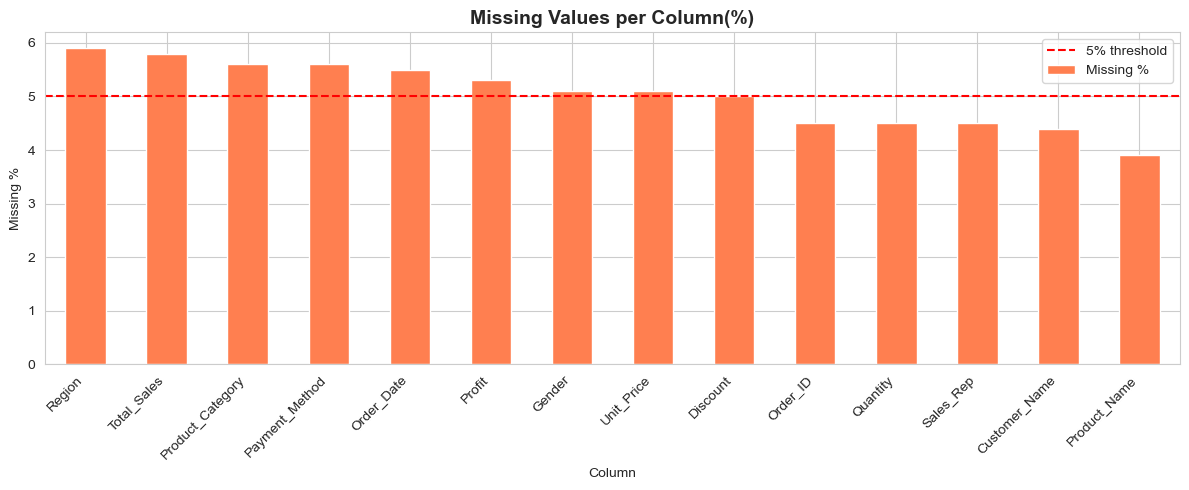

In [38]:
#visualize missing values as bar chart

fig, ax = plt.subplots(figsize=(12, 5))
missing_Data['Missing %'].plot(kind='bar',color='coral',ax=ax)
ax.set_title('Missing Values per Column(%)',fontsize=14, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Missing %')
ax.axhline(5, color='red',linestyle='--',label = '5% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [40]:
  #unique valuesin categorical columns 
cat_cols = ['Gender','Region','Product_Category','Payment_Method','Sales_Rep']

for col in cat_cols:
    print(f'\n[PIN] {col}:')
    print(Data[col].value_counts(dropna=False).to_string())


[PIN] Gender:
Gender
Female    491
Male      458
NaN        51

[PIN] Region:
Region
South    258
East     239
West     232
North    212
NaN       59

[PIN] Product_Category:
Product_Category
Furniture      208
Electronics    204
Food           202
Clothing       184
Books          146
NaN             56

[PIN] Payment_Method:
Payment_Method
POS         253
Transfer    235
Online      234
Cash        222
NaN          56

[PIN] Sales_Rep:
Sales_Rep
Rep_D    251
Rep_A    249
Rep_C    230
Rep_B    225
NaN       45


In [41]:
# duplicate rows
dupes = Data.duplicated().sum()
print(f'Number of fully duplicate rows: (dupes)')

Number of fully duplicate rows: (dupes)


In [19]:
# data cleaning (working copy)
Data_clean = Data.copy()
print(f'Working copy created. Shape:{Data_clean.shape}')

Working copy created. Shape:(1000, 14)


In [46]:
#Fix the Order_Date column (text->datetime
Data_clean['Order_Date'] = pd.to_datetime(Data_clean['Order_Date'],errors='coerce')

print('Order_Date dtype after fix',Data_clean['Order_Date'].dtype)
print('Sample dates:',Data_clean['Order_Date'].dropna().head(5).tolist()) 

Order_Date dtype after fix datetime64[ns]
Sample dates: [Timestamp('2022-07-18 00:00:00'), Timestamp('2024-09-18 00:00:00'), Timestamp('2023-09-11 00:00:00'), Timestamp('2022-06-03 00:00:00'), Timestamp('2023-07-12 00:00:00')]


In [47]:
# remove duplicate rows

before = len(Data_clean)
Data_clean.drop_duplicates(inplace=True)
after = len(Data_clean)

print(f'Rows before: (before) | After: {after} | Removed: {before - after}')


Rows before: (before) | After: 1000 | Removed: 0


In [20]:
# handl missing values in numeric columns
Data_clean['Quantity']    = Data_clean['Quantity'].fillna(Data_clean['Quantity'].median())

In [23]:
 # Handle missing values in NUMERIC columns

Data_clean['Quantity'] = Data_clean['Quantity'].fillna(
    Data_clean['Quantity'].median()
)

Data_clean['Unit_Price'] = Data_clean['Unit_Price'].fillna(
    Data_clean['Unit_Price'].median()
)

Data_clean['Total_Sales'] = Data_clean['Total_Sales'].fillna(
    Data_clean['Total_Sales'].median()
)

Data_clean['Profit'] = Data_clean['Profit'].fillna(
    Data_clean['Profit'].median()
)

Data_clean['Discount'] = Data_clean['Discount'].fillna(0)


print('Numeric columns — remaining missing values:')
print(
    Data_clean[['Quantity', 'Unit_Price', 'Total_Sales', 'Profit', 'Discount']]
    .isnull()
    .sum()
)

Numeric columns — remaining missing values:
Quantity       0
Unit_Price     0
Total_Sales    0
Profit         0
Discount       0
dtype: int64


In [24]:
# Handle missing values in CATEGORICAL columns
for col in ['Gender', 'Region', 'Product_Category', 'Payment_Method']: 
    mode_val = Data_clean[col].mode()[0] 
    Data_clean[col].fillna(mode_val, inplace=True) 
  
for col in ['Sales_Rep', 'Customer_Name', 'Order_ID', 'Product_Name']: 
    Data_clean[col].fillna('Unknown', inplace=True) 
  
Data_clean.dropna(subset=['Order_Date'], inplace=True) 
  
print('Remaining missing values after cleaning:') 
print(Data_clean.isnull().sum())

Remaining missing values after cleaning:
Order_ID            0
Customer_Name       0
Gender              0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Total_Sales         0
Discount            0
Profit              0
Order_Date          0
Payment_Method      0
Sales_Rep           0
dtype: int64


In [48]:
Data_clean['Year']          = Data_clean['Order_Date'].dt.year 
Data_clean['Month']         = Data_clean['Order_Date'].dt.month 
Data_clean['Month_Name']    = Data_clean['Order_Date'].dt.strftime('%b') 
Data_clean['Quarter']       = Data_clean['Order_Date'].dt.to_period('Q').astype(str) 
Data_clean['Profit_Margin'] = (Data_clean['Profit'] / Data_clean['Total_Sales'] * 
100).round(2) 
  
print('New columns added:', 
['Year',\'Month','Month_Name','Quarter','Profit_Margin']) 
Data_clean[['Order_Date','Year','Month','Month_Name','Quarter','Profit_Margin']].head


print(f'Clean dataset shape: {df_clean.shape}') 
print(f'Rows removed during cleaning: {len(df) - len(Data_clean)}') 
Data_clean.head(3)


SyntaxError: unexpected character after line continuation character (811211602.py, line 9)

In [28]:
# Final check after cleaning 
print(f'Clean dataset shape: {Data_clean.shape}') 
print(f'Rows removed during cleaning: {len(Data) - len(Data_clean)}') 
Data_clean.head(3) 


Clean dataset shape: (945, 14)
Rows removed during cleaning: 55


,Order_ID,Customer_Name,Gender,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Order_Date,Payment_Method,Sales_Rep
0,ORD1001,Zainab James,Female,West,Electronics,Laptop,3.0,21785.0,65355.0,4346.0,11889.607718,2022-07-18,Cash,Rep_D
1,Unknown,Zainab Okafor,Male,East,Clothing,Jeans,2.0,69255.0,138510.0,903.0,17920.557815,2024-09-18,Online,Rep_A
2,ORD1003,Samuel Abdullahi,Male,South,Clothing,Shirt,9.0,106459.0,958131.0,171.0,56257.963706,2023-09-11,POS,Rep_C


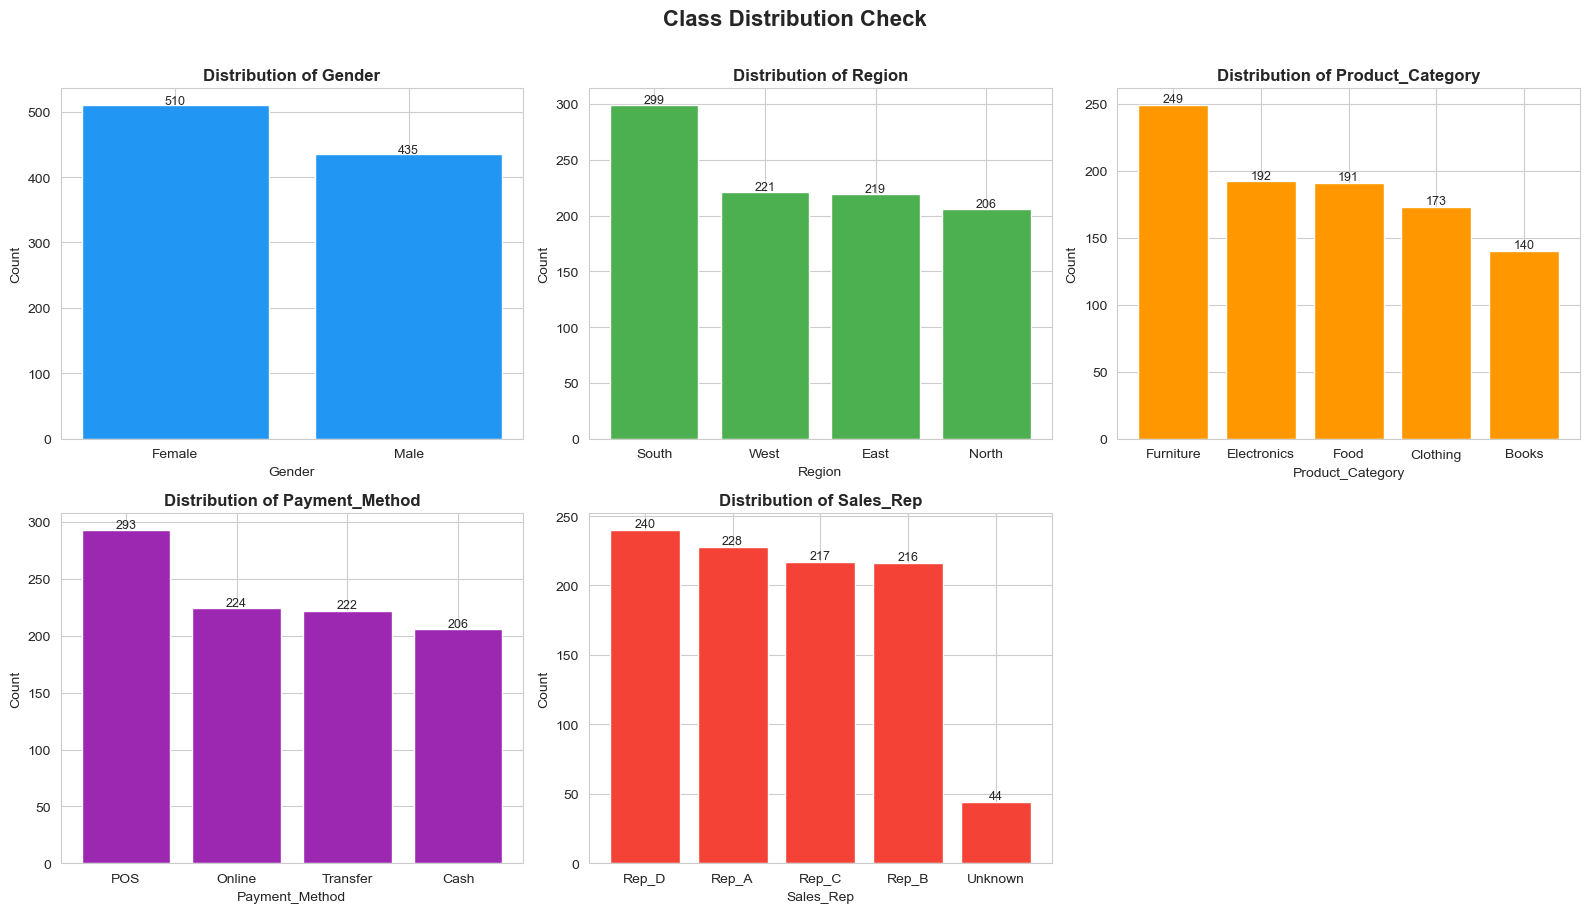

In [30]:
# stage 3 Check distribution of key categorical columns 
fig, axes = plt.subplots(2, 3, figsize=(16, 9)) 
axes = axes.flatten() 
  
cat_cols = ['Gender', 'Region', 'Product_Category', 'Payment_Method', 'Sales_Rep'] 
colors   = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336'] 
  
for i, col in enumerate(cat_cols): 
    counts = Data_clean[col].value_counts() 
    axes[i].bar(counts.index, counts.values, color=colors[i], edgecolor='white') 
    axes[i].set_title(f'Distribution of {col}', fontweight='bold') 
    axes[i].set_xlabel(col) 
    axes[i].set_ylabel('Count') 
    for j, v in enumerate(counts.values): 
        axes[i].text(j, v + 2, str(v), ha='center', fontsize=9) 
  
axes[5].set_visible(False) 
plt.suptitle('Class Distribution Check', fontsize=16, fontweight='bold', y=1.01) 
plt.tight_layout() 
plt.show()

In [31]:
#Measure imbalance ratio 
print('Imbalance Ratios (max / min count per category)\n') 
for col in cat_cols: 
    counts = Data_clean[col].value_counts() 
    ratio  = counts.max() / counts.min() 
    status = 'Balanced' if ratio <= 2.0 else '⚠️ Imbalanced' 
    print(f'{col:<20} Ratio: {ratio:.2f}  {status}') 

Imbalance Ratios (max / min count per category)

Gender               Ratio: 1.17  Balanced
Region               Ratio: 1.45  Balanced
Product_Category     Ratio: 1.78  Balanced
Payment_Method       Ratio: 1.42  Balanced
Sales_Rep            Ratio: 5.45  ⚠️ Imbalanced


In [33]:
Data_balanced = 

AttributeError: 'DataFrame' object has no attribute 'status'

NameError: name 'Data_balanced' is not defined

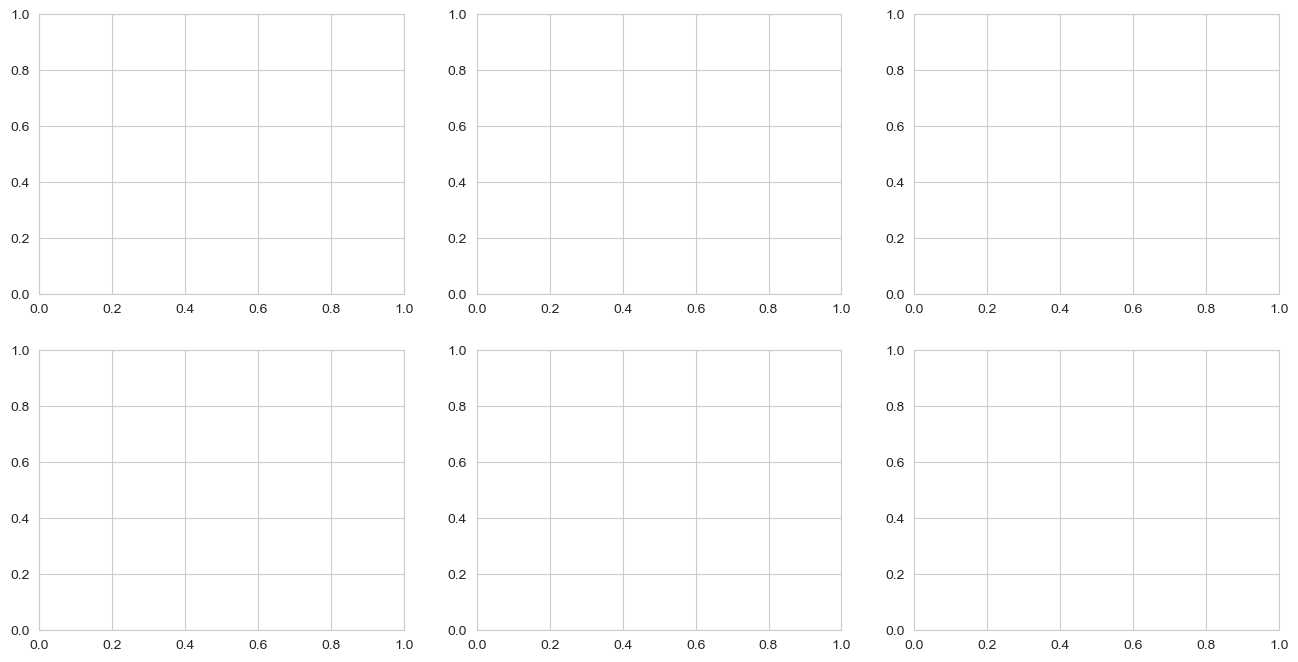

In [32]:
   #Numeric feature distribution (histograms)
num_cols = ['Quantity', 'Unit_Price', 'Total_Sales', 'Profit', 'Discount'] 
  
fig, axes = plt.subplots(2, 3, figsize=(16, 8)) 
axes = axes.flatten() 
  
for i, col in enumerate(num_cols): 
    axes[i].hist(Data_balanced[col], bins=30, color='#1976D2', 
                 edgecolor='white', alpha=0.85) 
    axes[i].set_title(f'Distribution: {col}', fontweight='bold') 
    axes[i].set_xlabel(col) 
    axes[i].set_ylabel('Frequency') 
  
axes[5].set_visible(False) 
plt.suptitle('Numeric Feature Distributions', fontsize=15, fontweight='bold') 
plt.tight_layout() 
plt.show()

In [36]:
# stage 4 Exploratory Data Analysis (EDA) Total Sales by Product Category 
cat_sales = Data_balanced.groupby('Product_Category')['Total_Sales'].sum()  .sort_values(ascending=True) 
  
fig, ax = plt.subplots(figsize=(10, 5)) 
colors  = plt.cm.Blues(np.linspace(0.4, 0.9, len(cat_sales))) 
bars    = ax.barh(cat_sales.index, cat_sales.values / 1e6, color=colors, 
edgecolor='white') 
  
for bar, val in zip(bars, cat_sales.values): 
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'₦{val/1e6:.1f}M', va='center', fontsize=9) 
  
ax.set_title('Total Sales by Product Category', fontsize=14, fontweight='bold') 
ax.set_xlabel('Total Sales (Millions ₦)') 
plt.tight_layout() 
plt.show()

NameError: name 'Data_balanced' is not defined

In [ ]:
output_path = 'sales_records_cleaned.xlsx' 
df_balanced.to_excel(output_path, index=False) 
print(f' Cleaned dataset saved to: {output_path}') 
print(f'   Final shape: {df_balanced.shape[0]:,} rows × {df_balanced.shape[1]} 
columns')